<a href="https://colab.research.google.com/github/alkadevirajbanshi-ai/Machine-Learning-On-Big-Data2/blob/main/Bitcoin_Historical_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("BitCoinForecasting")
    .master("local[*]")
    .getOrCreate()
)

spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = spark.read.csv('/content/drive/MyDrive/datasets/btcusd_1-min_data.csv',inferSchema=True, header =True)

df.head()

Row(Timestamp=1325376060, Open=4.58, High=4.58, Low=4.58, Close=4.58, Volume=0.0)

In [5]:
DATA_PATH = "/content/drive/MyDrive/datasets/btcusd_1-min_data.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df.printSchema()
df.show(5)
print("Row count:", df.count())

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows
Row count: 7675292


In [6]:
# Re-read the DataFrame to ensure 'Timestamp' is available for transformation
# This addresses the 'UNRESOLVED_COLUMN' error if 'df' was previously altered
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df = df.withColumn("Date", F.to_date(F.from_unixtime(F.col("Timestamp"))))

# Keep only the columns needed for the forecasting pipeline
cols_needed = ["Date", "Open", "High", "Low", "Close", "Volume"]
df = df.select(*cols_needed)

# Drop rows with any nulls in the key columns
df = df.dropna(subset=cols_needed)

# Sort chronologically — critical for time-series feature generation
df = df.orderBy("Date")

df.show(5)
print("Row count after cleaning:", df.count())

+----------+----+----+----+-----+------+
|      Date|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows
Row count after cleaning: 7675292


In [7]:
# Window ordered by Date for lag features (row-based)
w = Window.orderBy("Date")

# Window for rolling statistics (trailing N rows, inclusive of current row)
w_roll5 = Window.orderBy("Date").rowsBetween(-4, 0)
w_roll10 = Window.orderBy("Date").rowsBetween(-9, 0)

df_feat = (
    df
    .withColumn("lag_1", F.lag("Close", 1).over(w))
    .withColumn("lag_2", F.lag("Close", 2).over(w))
    .withColumn("lag_3", F.lag("Close", 3).over(w))
    .withColumn("lag_5", F.lag("Close", 5).over(w))
    .withColumn("rolling_mean_5", F.avg("Close").over(w_roll5))
    .withColumn("rolling_std_5", F.stddev("Close").over(w_roll5))
    .withColumn("rolling_mean_10", F.avg("Close").over(w_roll10))
    .withColumn("rolling_std_10", F.stddev("Close").over(w_roll10))
    .withColumn("daily_return", (F.col("Close") - F.lag("Close", 1).over(w)) / F.lag("Close", 1).over(w))
)

df_feat.show(10)

+----------+----+----+----+-----+------+-----+-----+-----+-----+--------------+-------------+-----------------+--------------+------------+
|      Date|Open|High| Low|Close|Volume|lag_1|lag_2|lag_3|lag_5|rolling_mean_5|rolling_std_5|  rolling_mean_10|rolling_std_10|daily_return|
+----------+----+----+----+-----+------+-----+-----+-----+-----+--------------+-------------+-----------------+--------------+------------+
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| NULL| NULL| NULL| NULL|          4.58|         NULL|             4.58|          NULL|        NULL|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| NULL| NULL| NULL|          4.58|          0.0|             4.58|           0.0|         0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| NULL| NULL|          4.58|          0.0|             4.58|           0.0|         0.0|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| 4.58| NULL|          4.58|          0.0|             4.58|           0.0|         0.0|
|2012-01-01|4.58|4.5

In [8]:
# Target: next day's Close price (forecast horizon = 1 day ahead)
w_lead = Window.orderBy("Date")
df_supervised = df_feat.withColumn("target", F.lead("Close", 1).over(w_lead))

# Drop rows with nulls introduced by lag/rolling windows and the final row (no future target)
feature_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "lag_1", "lag_2", "lag_3", "lag_5",
    "rolling_mean_5", "rolling_std_5",
    "rolling_mean_10", "rolling_std_10",
    "daily_return"
]

df_supervised = df_supervised.dropna(subset=feature_cols + ["target"])

print("Row count after feature/target engineering:", df_supervised.count())
df_supervised.select("Date", *feature_cols, "target").show(10)

Row count after feature/target engineering: 7675286
+----------+----+----+----+-----+------+-----+-----+-----+-----+--------------+-------------+-----------------+--------------+------------+------+
|      Date|Open|High| Low|Close|Volume|lag_1|lag_2|lag_3|lag_5|rolling_mean_5|rolling_std_5|  rolling_mean_10|rolling_std_10|daily_return|target|
+----------+----+----+----+-----+------+-----+-----+-----+-----+--------------+-------------+-----------------+--------------+------------+------+
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| 4.58| 4.58|          4.58|          0.0|4.579999999999999|           0.0|         0.0|  4.58|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| 4.58| 4.58|          4.58|          0.0|4.579999999999999|           0.0|         0.0|  4.58|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| 4.58| 4.58|          4.58|          0.0|4.579999999999999|           0.0|         0.0|  4.58|
|2012-01-01|4.58|4.58|4.58| 4.58|   0.0| 4.58| 4.58| 4.58| 4.58|  

In [9]:
# Add a row index to perform a chronological split
df_indexed = df_supervised.withColumn("row_id", F.row_number().over(Window.orderBy("Date")))

total_rows = df_indexed.count()
split_point = int(total_rows * 0.8)

train_df = df_indexed.filter(F.col("row_id") <= split_point)
test_df = df_indexed.filter(F.col("row_id") > split_point)

print(f"Total rows: {total_rows}")
print(f"Train rows: {train_df.count()}  (up to {train_df.agg(F.max('Date')).first()[0]})")
print(f"Test rows:  {test_df.count()}  (from {test_df.agg(F.min('Date')).first()[0]})")

Total rows: 7675286
Train rows: 6140228  (up to 2023-09-04)
Test rows:  1535058  (from 2023-09-04)


In [10]:
# Assemble features into a single vector column required by Spark ML
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_vec = assembler.transform(train_df).select("Date", "features", "target")
test_vec = assembler.transform(test_df).select("Date", "features", "target")

train_vec.show(5, truncate=False)

+----------+--------------------------------------------------------------------------------+------+
|Date      |features                                                                        |target|
+----------+--------------------------------------------------------------------------------+------+
|2012-01-01|[4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,4.58,0.0,4.579999999999999,0.0,0.0]|4.58  |
|2012-01-01|[4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,4.58,0.0,4.579999999999999,0.0,0.0]|4.58  |
|2012-01-01|[4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,4.58,0.0,4.579999999999999,0.0,0.0]|4.58  |
|2012-01-01|[4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,4.58,0.0,4.579999999999999,0.0,0.0]|4.58  |
|2012-01-01|[4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,4.58,0.0,4.579999999999999,0.0,0.0]|4.58  |
+----------+--------------------------------------------------------------------------------+------+
only showing top 5 rows


In [11]:
# --- Linear Regression (baseline) ---
lr = LinearRegression(featuresCol="features", labelCol="target")
lr_model = lr.fit(train_vec)

lr_predictions = lr_model.transform(test_vec)
lr_predictions.select("Date", "target", "prediction").show(10)

+----------+-------+------------------+
|      Date| target|        prediction|
+----------+-------+------------------+
|2023-09-04|25921.0| 25920.53755732323|
|2023-09-04|25921.0|25920.387371502155|
|2023-09-04|25912.0|25920.509060149165|
|2023-09-04|25912.0|25912.700543461626|
|2023-09-04|25908.0|25911.611272449794|
|2023-09-04|25908.0|25908.344999056444|
|2023-09-04|25902.0|25907.480679215016|
|2023-09-04|25899.0|25901.991426095705|
|2023-09-04|25899.0|25898.694288258448|
|2023-09-04|25898.0|25898.875089306388|
+----------+-------+------------------+
only showing top 10 rows


In [12]:
# --- Gradient Boosted Trees (non-linear) ---
gbt = GBTRegressor(featuresCol="features", labelCol="target", maxIter=100, maxDepth=5, seed=42)
gbt_model = gbt.fit(train_vec)

gbt_predictions = gbt_model.transform(test_vec)
gbt_predictions.select("Date", "target", "prediction").show(10)

+----------+-------+------------------+
|      Date| target|        prediction|
+----------+-------+------------------+
|2023-09-04|25921.0|  24846.5162796158|
|2023-09-04|25921.0| 24894.22174762831|
|2023-09-04|25912.0| 25102.24459932318|
|2023-09-04|25912.0| 24505.74809867876|
|2023-09-04|25908.0|24695.833960733737|
|2023-09-04|25908.0|24648.455604440704|
|2023-09-04|25902.0|24695.833960733737|
|2023-09-04|25899.0|24467.992946705323|
|2023-09-04|25899.0|24615.808207518417|
|2023-09-04|25898.0| 24671.93771900907|
+----------+-------+------------------+
only showing top 10 rows


In [13]:
evaluator_rmse = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="r2")

results = []
for name, preds in [("Linear Regression", lr_predictions), ("Gradient Boosted Trees", gbt_predictions)]:
    rmse = evaluator_rmse.evaluate(preds)
    mae = evaluator_mae.evaluate(preds)
    r2 = evaluator_r2.evaluate(preds)
    results.append((name, rmse, mae, r2))
    print(f"{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
results_df

Linear Regression         | RMSE: 50.8240 | MAE: 30.4799 | R2: 1.0000
Gradient Boosted Trees    | RMSE: 28646.8032 | MAE: 21229.5963 | R2: -0.3599


,Model,RMSE,MAE,R2
0,Linear Regression,50.824022,30.479902,0.999996
1,Gradient Boosted Trees,28646.803204,21229.596348,-0.359936


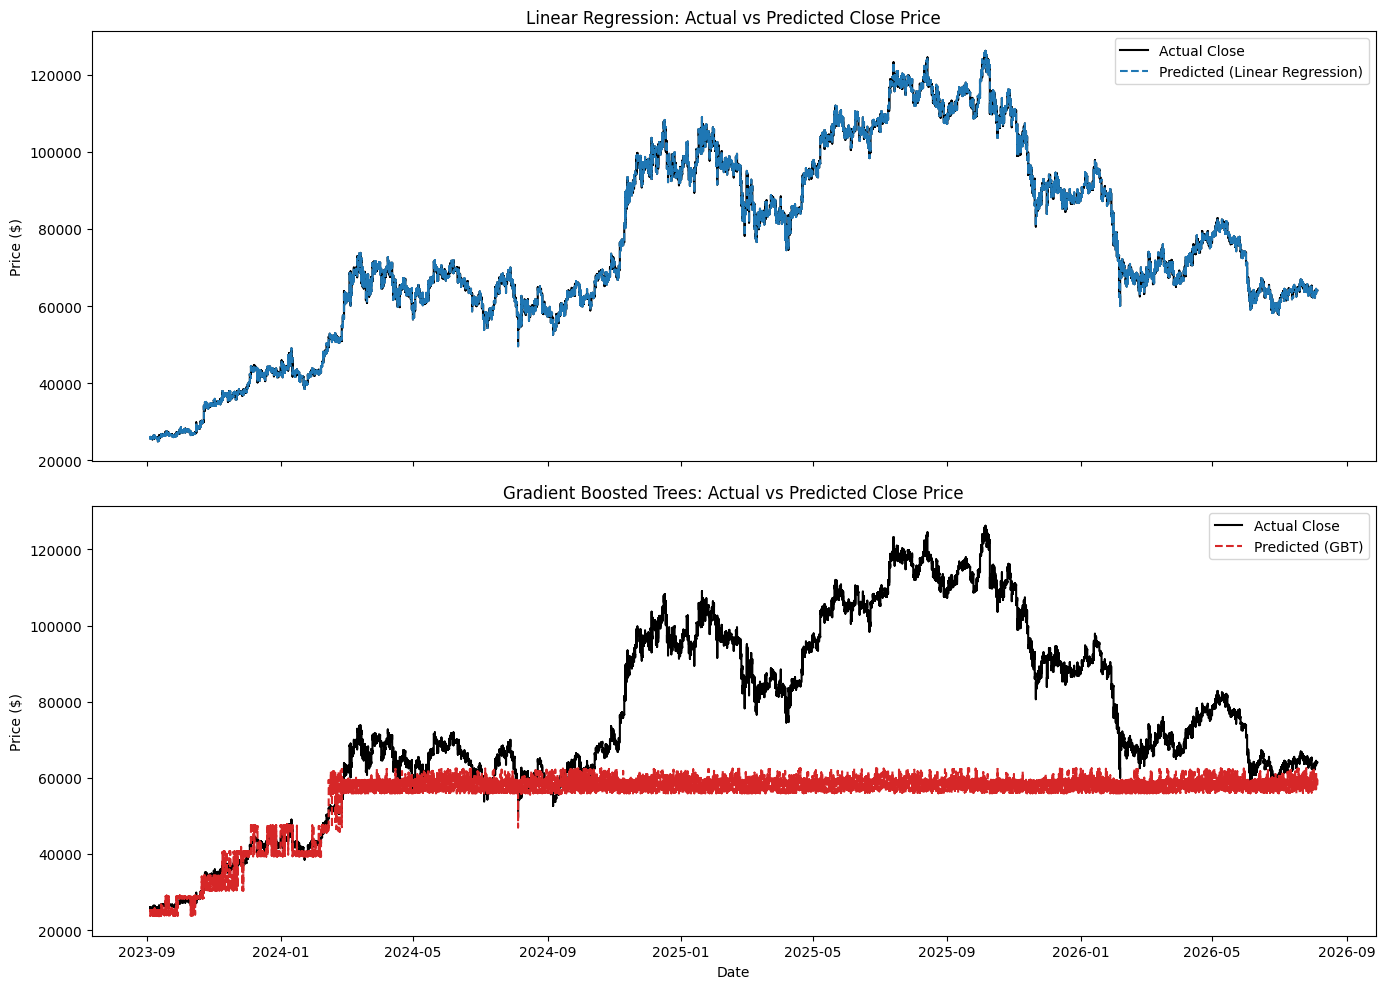

In [14]:

# Convert predictions to pandas for plotting (test set is small enough to collect)
lr_pd = lr_predictions.select("Date", "target", "prediction").orderBy("Date").toPandas()
gbt_pd = gbt_predictions.select("Date", "target", "prediction").orderBy("Date").toPandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(lr_pd["Date"], lr_pd["target"], label="Actual Close", color="black", linewidth=1.5)
axes[0].plot(lr_pd["Date"], lr_pd["prediction"], label="Predicted (Linear Regression)", color="tab:blue", linestyle="--")
axes[0].set_title("Linear Regression: Actual vs Predicted Close Price")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

axes[1].plot(gbt_pd["Date"], gbt_pd["target"], label="Actual Close", color="black", linewidth=1.5)
axes[1].plot(gbt_pd["Date"], gbt_pd["prediction"], label="Predicted (GBT)", color="tab:red", linestyle="--")
axes[1].set_title("Gradient Boosted Trees: Actual vs Predicted Close Price")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price ($)")
axes[1].legend()

plt.tight_layout()
plt.show()
